# Capstone Project: Analyzing Flight Delays

## Introduction

In this capstone project, we aim to analyze and predict flight delays using a comprehensive dataset that includes various features related to flights, weather conditions, and temporal factors. The dataset, `summer_data`, contains information about flights such as the reporting airline, origin and destination airports, number of flights, average delay, and distance. Additionally, it includes weather-related data like temperature, precipitation, wind speed, visibility, and ceiling height, as well as temporal data such as date, year, month, day, and whether the day falls on a weekend.

The primary objective of this project is to explore the factors contributing to flight delays and develop predictive models to estimate delays based on the available features. We will employ various machine learning techniques, including feature selection and regression models, to achieve this goal.

## Dataset Overview

The dataset includes the following key columns:
- **Reporting_Airline**: The airline reporting the flight data.
- **Origin** and **Dest**: The origin and destination airports.
- **Flights**: The number of flights.
- **AvgDelay**: The average delay in minutes.
- **Distance**: The distance between the origin and destination.
- **DATE**: The date of the flight.
- **TEMP**, **PRCP**, **WIND**, **VISIBILITY**, **CEILING**: Weather-related features.
- **Year**, **Month**, **Day**: Temporal features.
- **Season**: The season during which the flight took place.
- **WeatherCondition**: The weather condition at the time of the flight.
- **Airport**: The airport code.
- **TotalDelay**: The total delay in minutes.
- **DelayPerDistance**: The delay per unit distance.
- **IsWeekend**: A boolean indicating if the flight was on a weekend.
- **TemperatureCategory**: A categorical representation of temperature.
- **Delayed**: A binary indicator of whether the flight was delayed.

## Methodology

We will start by performing exploratory data analysis (EDA) to understand the distribution and relationships between different features. Following this, we will apply feature selection techniques to identify the most significant predictors of flight delays. Finally, we will build and evaluate machine learning models to predict flight delays, using metrics such as mean squared error and confusion matrix to assess model performance.

This project will provide insights into the factors affecting flight delays and demonstrate the application of data science techniques in the aviation industry.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import confusion_matrix

In [3]:
# Load the CSV file into a DataFrame
data = pd.read_csv('merged_data.csv')

data.head()  # Display the first few rows of the DataFrame

,Reporting_Airline,Origin,Dest,Flights,AvgDelay,Distance,DATE,TEMP,PRCP,WIND,VISIBILITY,CEILING,Year,Month,Day,Season,WeatherCondition,Airport,TotalDelay,DelayPerDistance,IsWeekend,TemperatureCategory
0,AA,ATL,BOS,24,10.516667,807.461929,2023-06-01,78.0,0.408,12.1,10.0,23432,2023,6,1,Summer,Moderate,ATL,252.4,0.013024,False,High
1,AA,ATL,BOS,24,10.516667,807.461929,2023-06-02,65.9,0.084,4.8,10.0,25598,2023,6,2,Summer,Mild,ATL,252.4,0.013024,False,High
2,AA,ATL,BOS,24,10.516667,807.461929,2023-06-03,84.6,0.456,1.9,4.8,19007,2023,6,3,Summer,Moderate,ATL,252.4,0.013024,True,High
3,AA,ATL,BOS,24,10.516667,807.461929,2023-06-04,77.8,0.120,22.9,6.4,12701,2023,6,4,Summer,Moderate,ATL,252.4,0.013024,True,High
4,AA,ATL,BOS,24,10.516667,807.461929,2023-06-05,82.6,0.180,2.4,7.2,25922,2023,6,5,Summer,Moderate,ATL,252.4,0.013024,False,High


make sure the data is clean and wrangled 

### Data Cleaning and Wrangling

Let's ensure that the data in the `merged_flight_data` DataFrame is clean and properly wrangled. We'll perform the following steps:

1. Check for missing values and handle them appropriately.
2. Ensure data types are correct.
3. Remove any duplicate rows.
4. Handle any outliers if necessary.
5. Verify the integrity of the data (e.g., logical consistency).

In [4]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Drop rows with missing values (if any)
cleaned_data = data.dropna()

# Check data types
print("\nData types of each column:\n", cleaned_data.dtypes)

# Remove duplicate rows
cleaned_data = cleaned_data.drop_duplicates()

# Display the cleaned data
cleaned_data.head()

Missing values in each column:
 Reporting_Airline      0
Origin                 0
Dest                   0
Flights                0
AvgDelay               0
Distance               0
DATE                   0
TEMP                   0
PRCP                   0
WIND                   0
VISIBILITY             0
CEILING                0
Year                   0
Month                  0
Day                    0
Season                 0
WeatherCondition       0
Airport                0
TotalDelay             0
DelayPerDistance       0
IsWeekend              0
TemperatureCategory    0
dtype: int64

Data types of each column:
 Reporting_Airline       object
Origin                  object
Dest                    object
Flights                  int64
AvgDelay               float64
Distance               float64
DATE                    object
TEMP                   float64
PRCP                   float64
WIND                   float64
VISIBILITY             float64
CEILING                  int64
Year

,Reporting_Airline,Origin,Dest,Flights,AvgDelay,Distance,DATE,TEMP,PRCP,WIND,VISIBILITY,CEILING,Year,Month,Day,Season,WeatherCondition,Airport,TotalDelay,DelayPerDistance,IsWeekend,TemperatureCategory
0,AA,ATL,BOS,24,10.516667,807.461929,2023-06-01,78.0,0.408,12.1,10.0,23432,2023,6,1,Summer,Moderate,ATL,252.4,0.013024,False,High
1,AA,ATL,BOS,24,10.516667,807.461929,2023-06-02,65.9,0.084,4.8,10.0,25598,2023,6,2,Summer,Mild,ATL,252.4,0.013024,False,High
2,AA,ATL,BOS,24,10.516667,807.461929,2023-06-03,84.6,0.456,1.9,4.8,19007,2023,6,3,Summer,Moderate,ATL,252.4,0.013024,True,High
3,AA,ATL,BOS,24,10.516667,807.461929,2023-06-04,77.8,0.120,22.9,6.4,12701,2023,6,4,Summer,Moderate,ATL,252.4,0.013024,True,High
4,AA,ATL,BOS,24,10.516667,807.461929,2023-06-05,82.6,0.180,2.4,7.2,25922,2023,6,5,Summer,Moderate,ATL,252.4,0.013024,False,High


In the code above, we:

- Checked for missing values and removed any rows containing them.
- Verified the data types of each column to ensure they are as expected.
- Removed any duplicate rows from the dataset.

Next, we can proceed to handle outliers and verify the logical consistency of the data if needed.

### Exploratory Data Analysis (EDA)

In this section, we will perform Exploratory Data Analysis (EDA) on the `merged_flight_data` DataFrame to gain insights into the data. The EDA will include:

1. Summary statistics of the dataset.
2. Distribution of numerical features.
3. Count of categorical features.
4. Correlation analysis between numerical features.
5. Analysis of relationships between key variables.

In [5]:
# Load the data
merged_flight_data = pd.read_csv('merged_data.csv')

# Display summary statistics
summary_stats = merged_flight_data.describe()
summary_stats

,Flights,AvgDelay,Distance,TEMP,PRCP,WIND,VISIBILITY,CEILING,Year,Month,Day,TotalDelay,DelayPerDistance
count,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000,890400.000000
mean,20.238095,4.580654,800.036401,54.689591,0.128636,9.845975,6.977638,19797.262893,2023.066038,5.823113,15.660377,92.407762,0.005729
std,4.478892,3.291232,21.145683,21.411647,0.128675,6.750260,2.287112,9822.050373,0.455964,3.650323,8.767319,67.858326,0.004121
min,7.000000,-7.663636,747.935000,-13.800000,0.000000,0.200000,0.000000,-11289.000000,2022.000000,1.000000,1.000000,-95.600000,-0.009490
25%,17.000000,2.374671,785.771574,39.000000,0.036000,4.900000,5.500000,12994.000000,2023.000000,2.000000,8.000000,45.200000,0.002991
50%,20.000000,4.409167,800.907438,55.300000,0.090000,8.400000,7.300000,19786.000000,2023.000000,6.000000,16.000000,86.600000,0.005547
75%,23.000000,6.632750,813.919786,71.100000,0.180000,13.000000,8.700000,26647.000000,2023.000000,9.000000,23.000000,132.025000,0.008381
max,37.000000,18.677778,855.230366,112.300000,0.990000,43.200000,10.000000,55190.000000,2024.000000,12.000000,31.000000,336.200000,0.022571


The table above shows the summary statistics for the numerical features in the dataset, including count, mean, standard deviation, minimum, and maximum values.

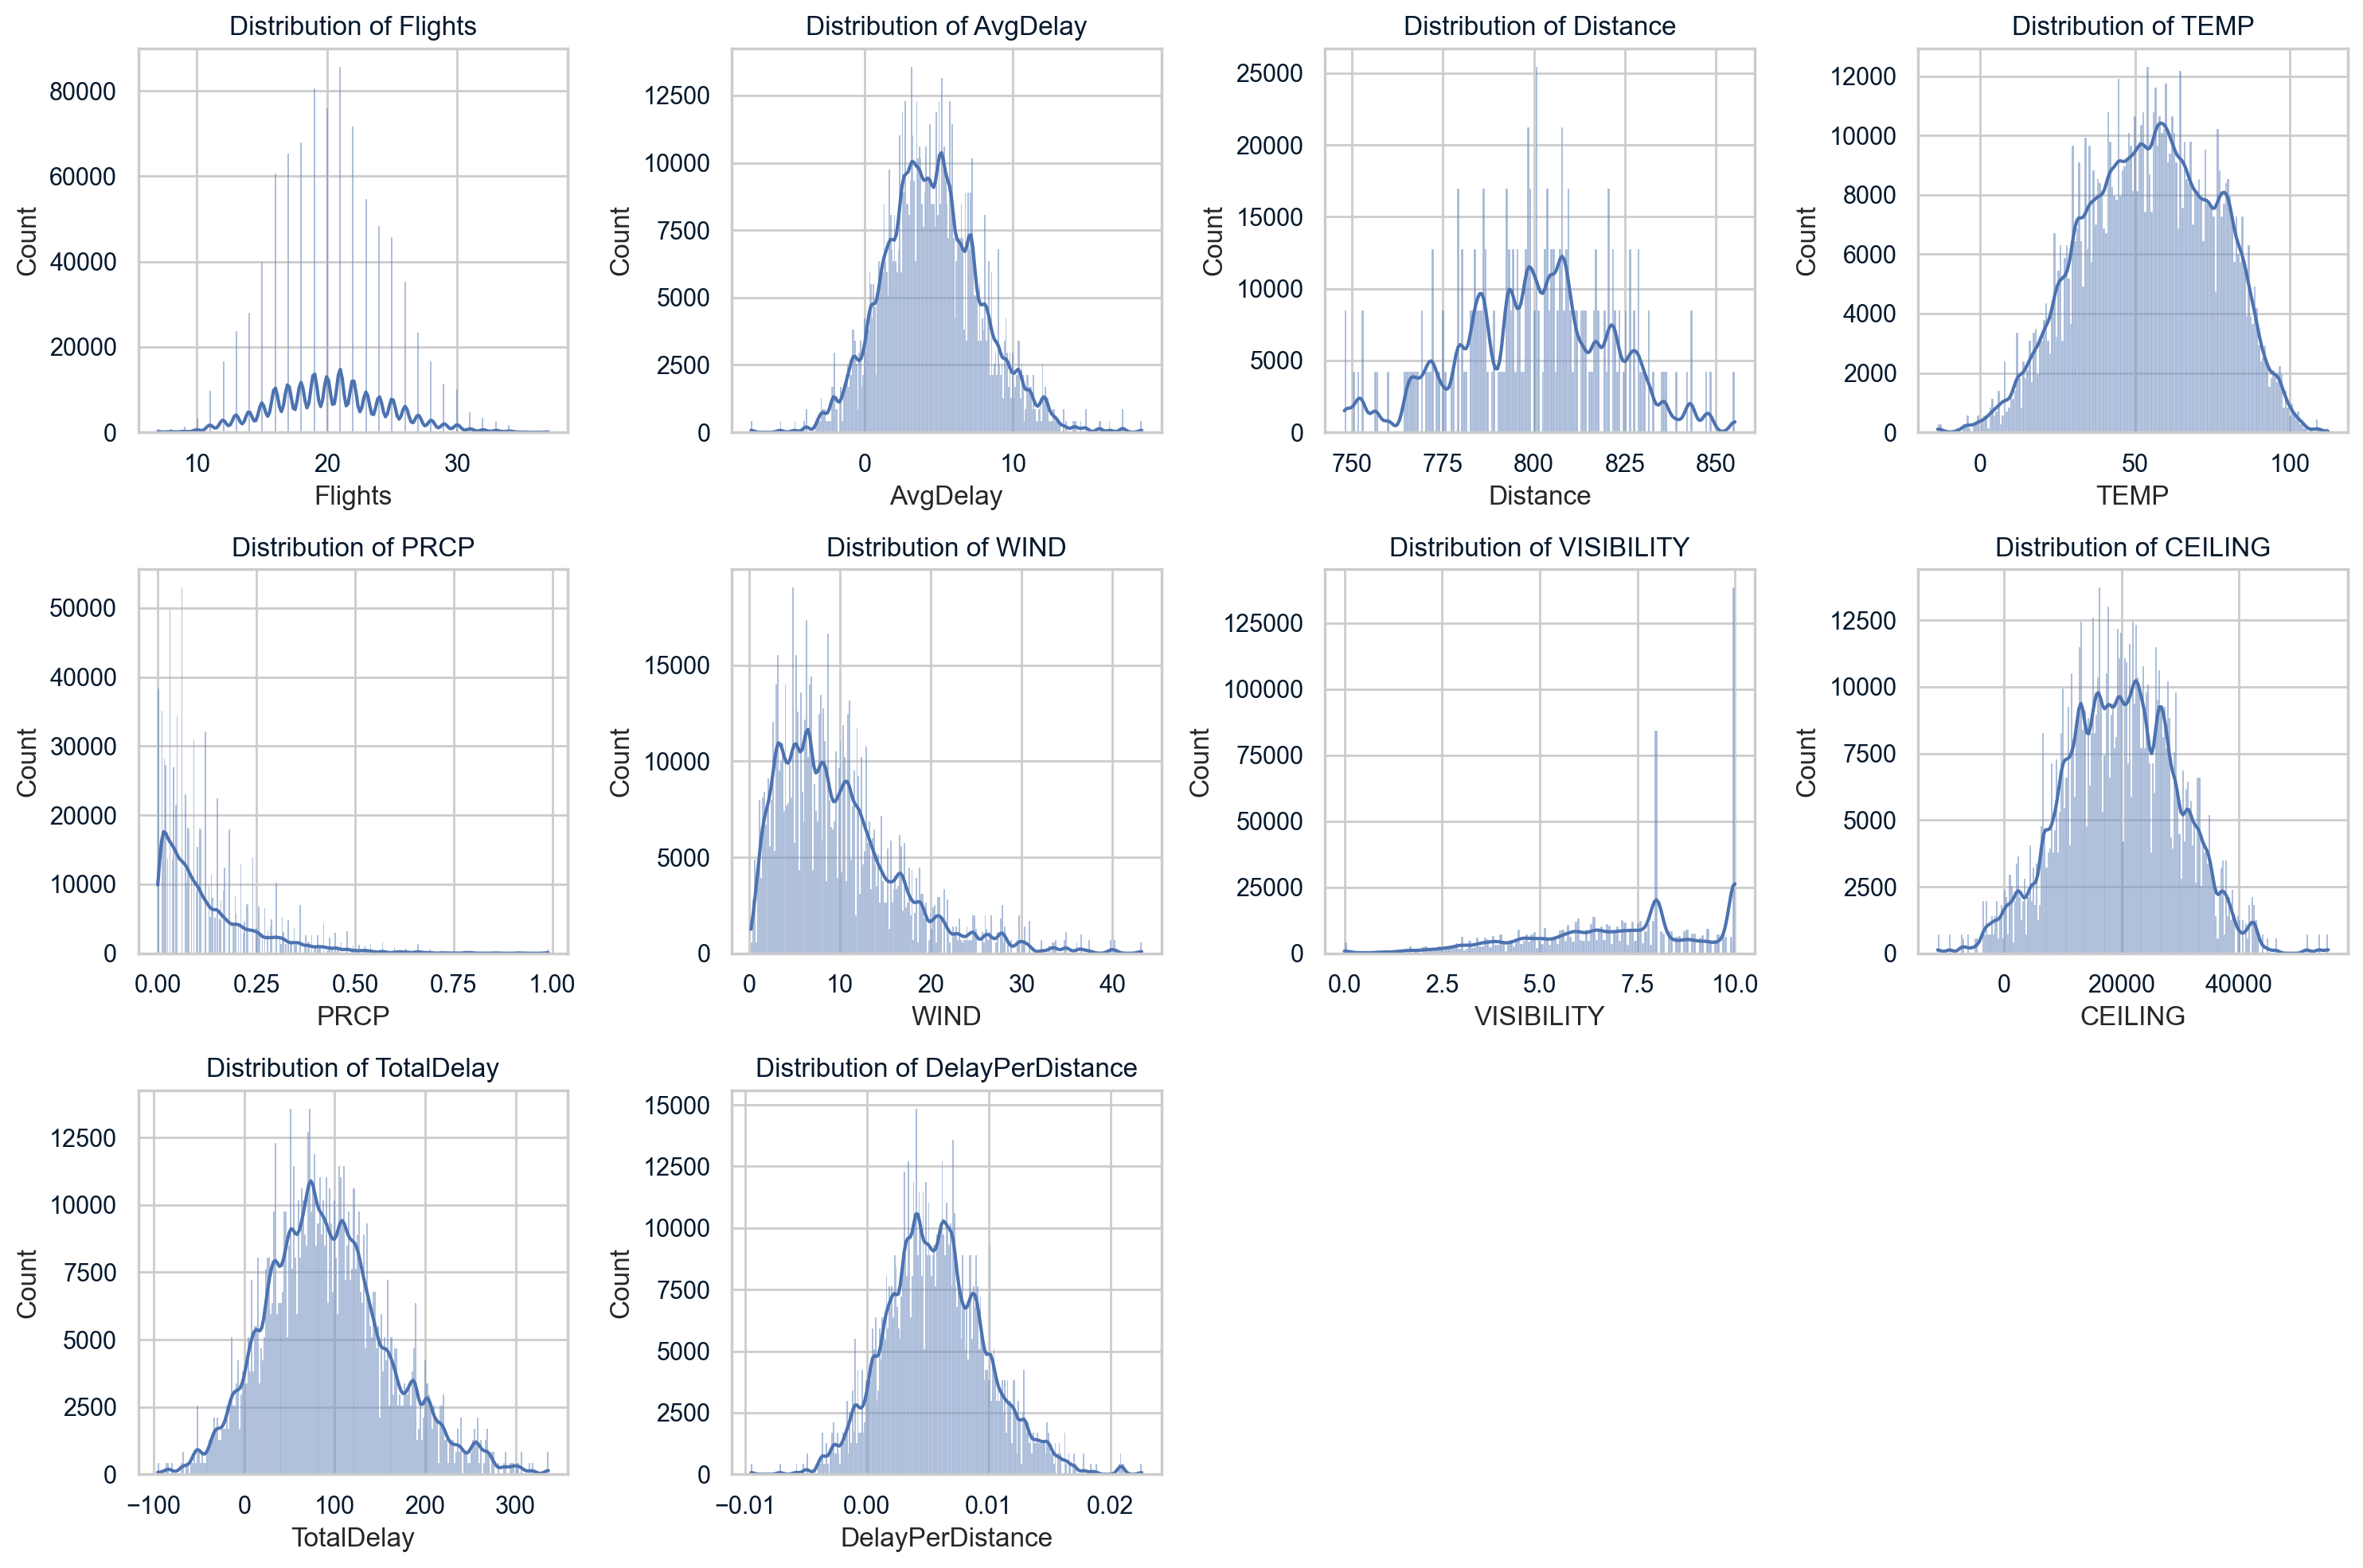

In [6]:
# Set the style of seaborn
sns.set(style="whitegrid")

# Plot distribution of numerical features
numerical_features = ['Flights', 'AvgDelay', 'Distance', 'TEMP', 'PRCP', 'WIND', 'VISIBILITY', 'CEILING', 'TotalDelay', 'DelayPerDistance']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 4, i+1)
    sns.histplot(merged_flight_data[feature], kde=True)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

The plots above show the distribution of each numerical feature in the dataset. This helps in understanding the spread and skewness of the data.

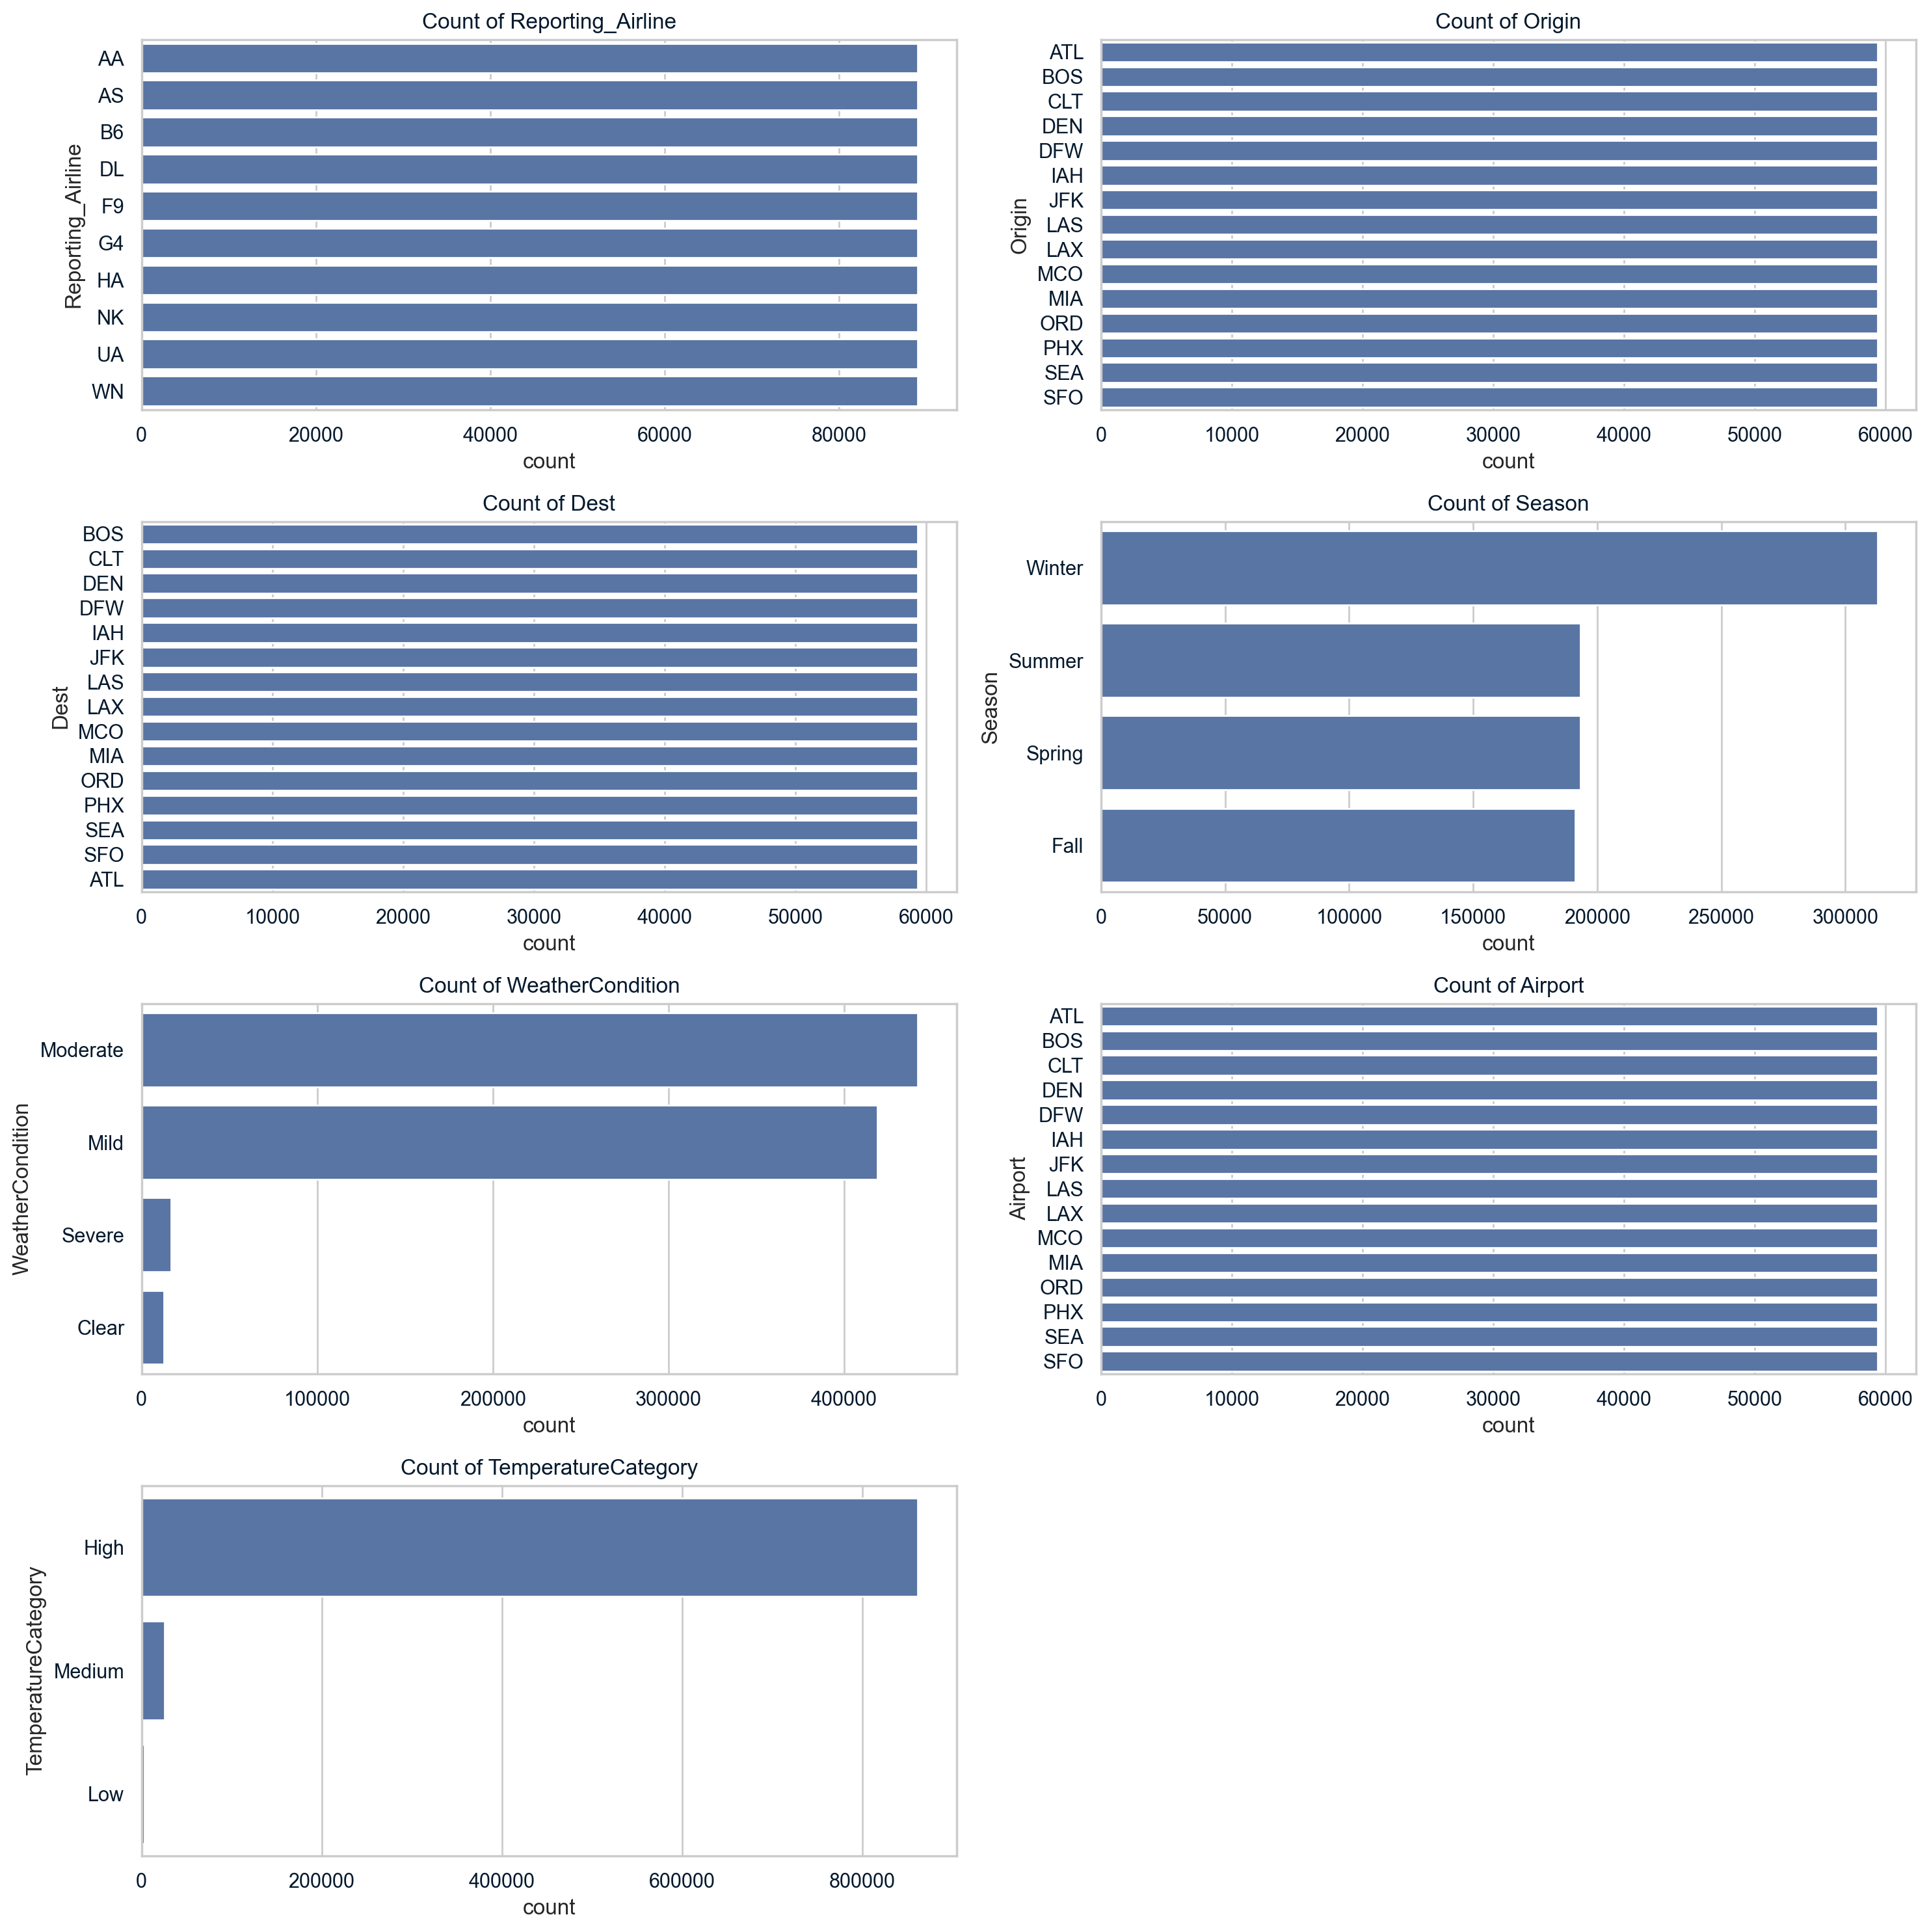

In [7]:
# Count plots for categorical features
categorical_features = ['Reporting_Airline', 'Origin', 'Dest', 'Season', 'WeatherCondition', 'Airport', 'TemperatureCategory']

plt.figure(figsize=(15, 15))
for i, feature in enumerate(categorical_features):
    plt.subplot(4, 2, i+1)
    sns.countplot(y=merged_flight_data[feature], order=merged_flight_data[feature].value_counts().index)
    plt.title(f'Count of {feature}')
plt.tight_layout()
plt.show()

The count plots above show the frequency of each category within the categorical features. This helps in understanding the distribution of categorical data.

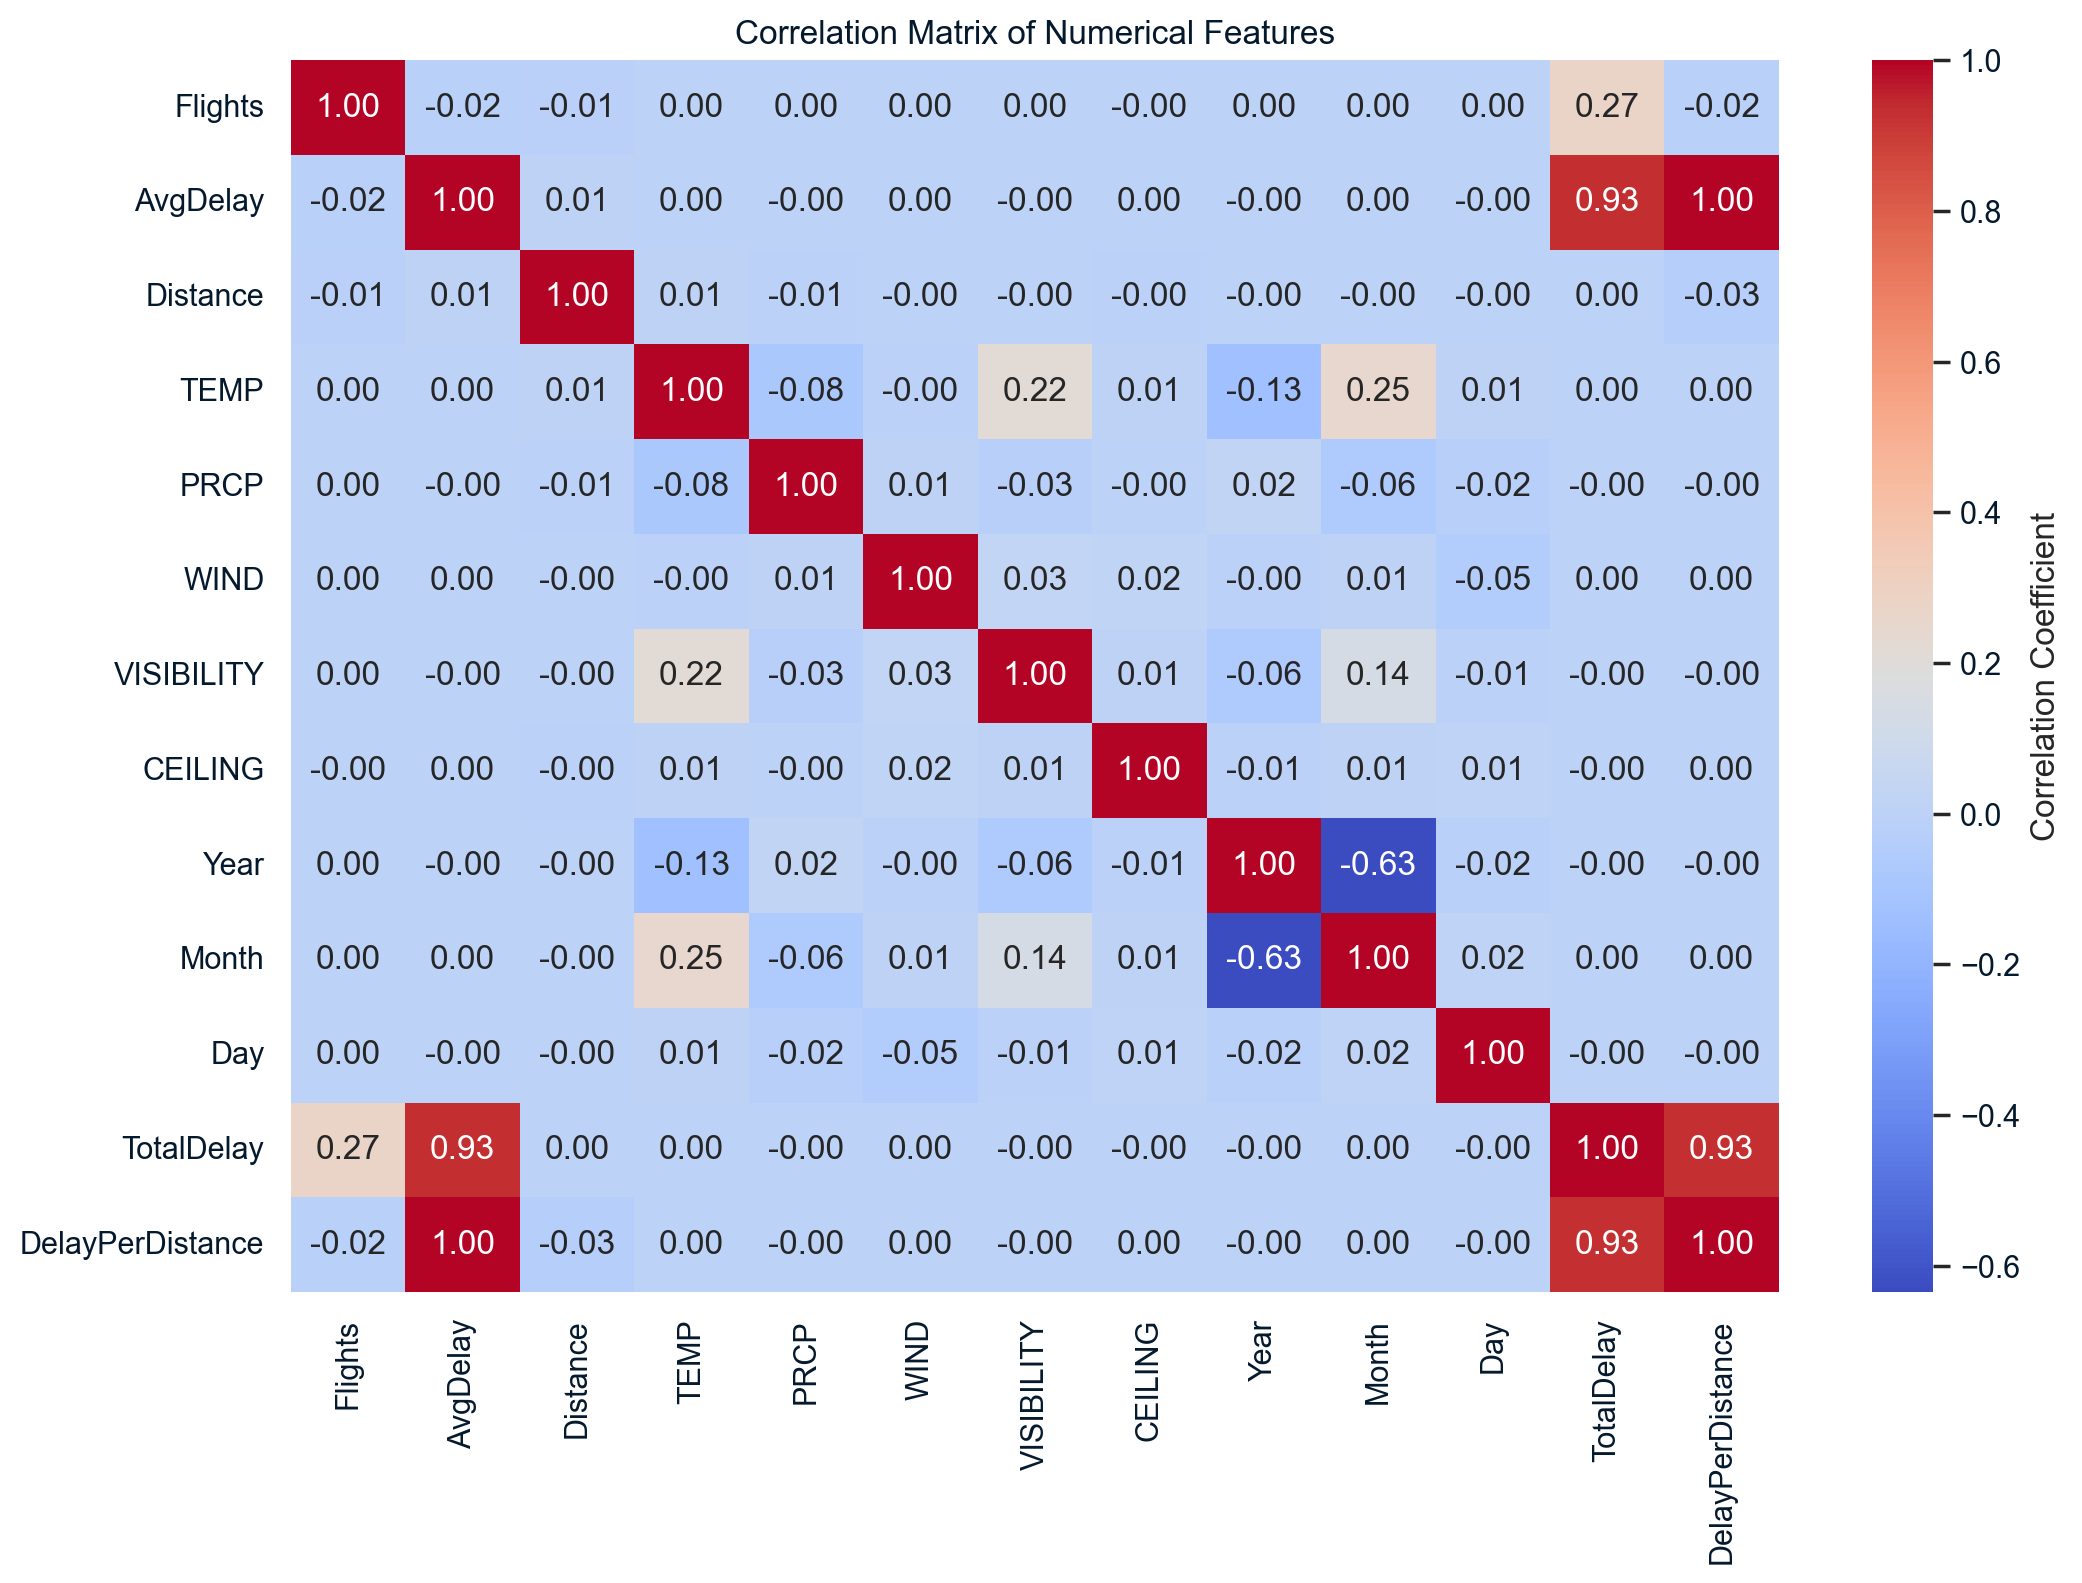

In [8]:
# Correlation matrix
# Select only numerical columns for correlation matrix calculation
numerical_data = merged_flight_data.select_dtypes(include=[np.number])
correlation_matrix = numerical_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The heatmap above displays the correlation matrix for the numerical features in the dataset. It helps in identifying the strength and direction of relationships between pairs of features.

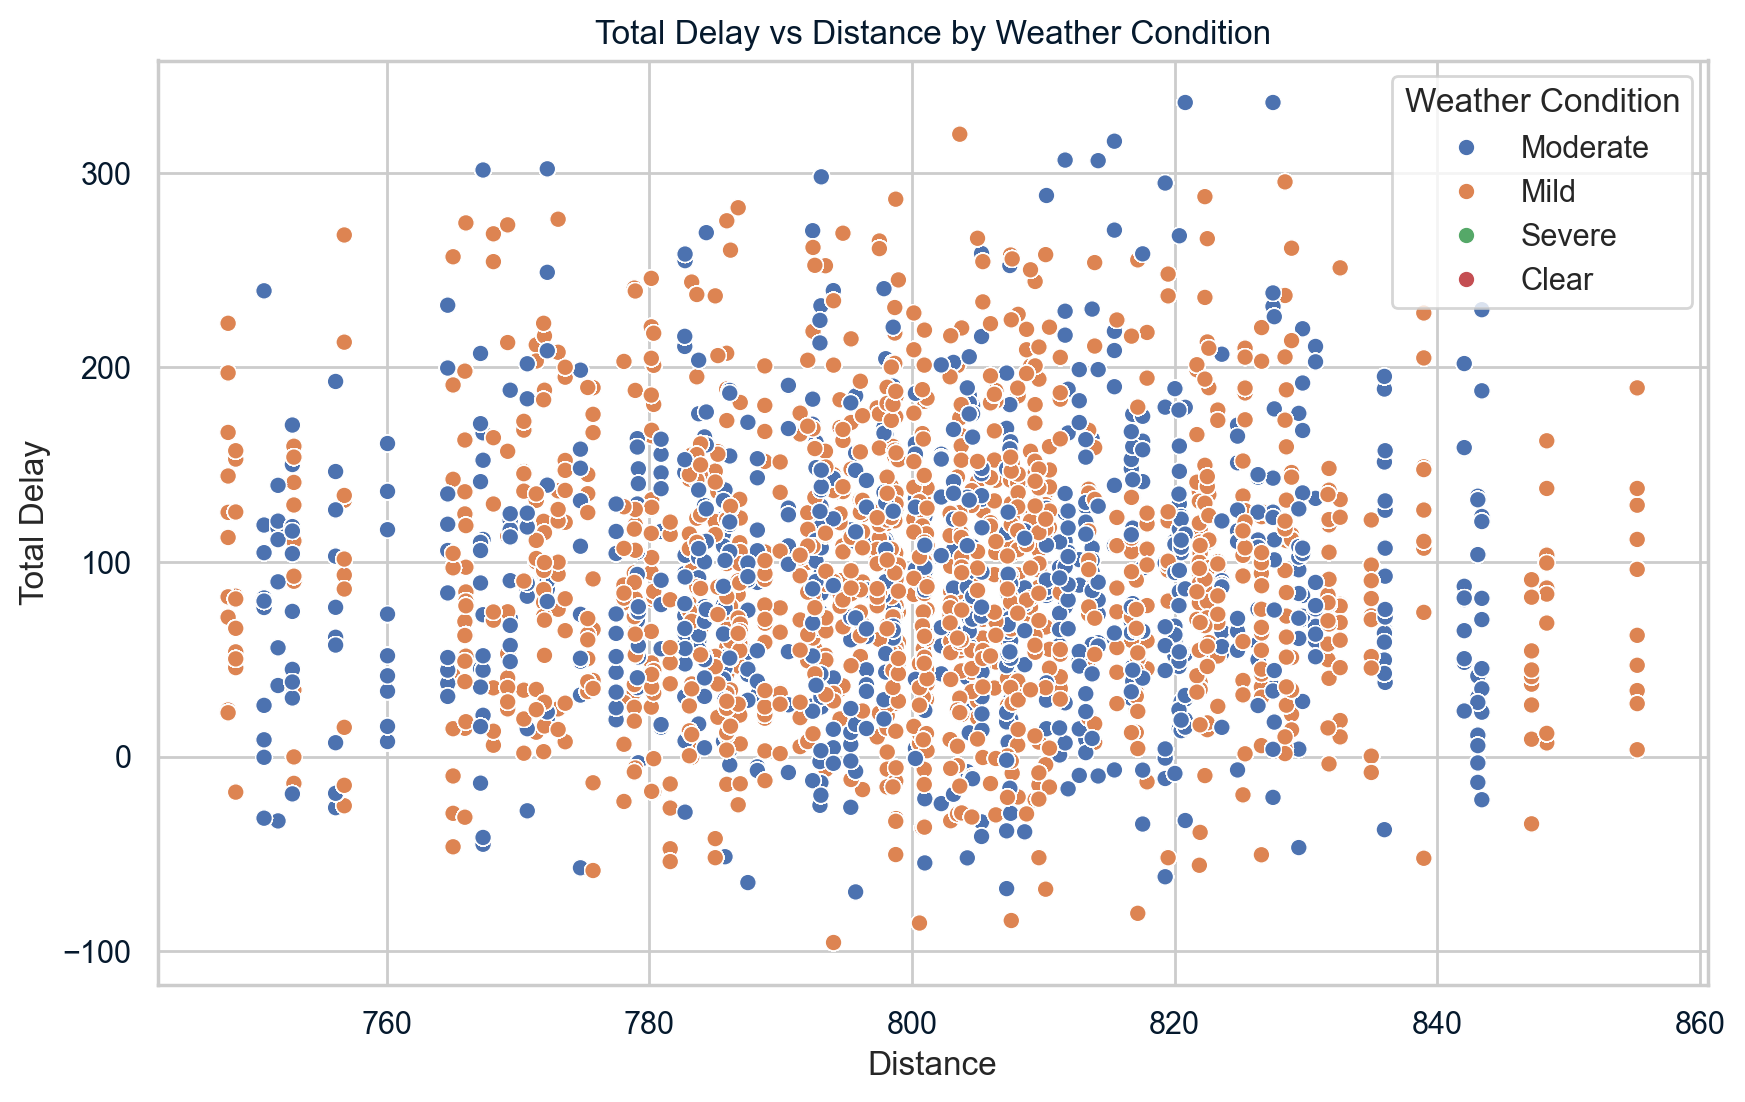

In [9]:
# Scatter plot for key relationships
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged_flight_data, x='Distance', y='TotalDelay', hue='WeatherCondition')
plt.title('Total Delay vs Distance by Weather Condition')
plt.xlabel('Distance')
plt.ylabel('Total Delay')
plt.legend(title='Weather Condition')
plt.show()

The scatter plot above shows the relationship between `Distance` and `TotalDelay`, colored by `WeatherCondition`. This helps in visualizing how delays vary with distance and different weather conditions.

## Feature Engineering

To improve the classification of delayed flights versus on-time flights, we can create new features that might capture additional information about the conditions under which delays occur. Here are some potential features to consider:

1. **Delay Ratio**: The ratio of `TotalDelay` to `Distance` can provide insight into how significant the delay is relative to the distance traveled.
2. **Weather Impact**: A feature that combines weather conditions such as `TEMP`, `PRCP`, `WIND`, and `VISIBILITY` into a single score or category.
3. **Time of Day**: Extract features like `Hour` from the `DATE` to see if certain times of day are more prone to delays.
4. **Day of Week**: Determine if certain days of the week have more delays by extracting this information from the `DATE`.
5. **Seasonal Effects**: Use the `Season` column to see if certain seasons have more delays.

Let's create these features in the dataset.

In [10]:
# Load the data
data = pd.read_csv('merged_data.csv')

# Feature 1: Delay Ratio
# Already exists as 'DelayPerDistance', but ensure it's calculated correctly
data['DelayPerDistance'] = data['TotalDelay'] / data['Distance']

# Feature 2: Weather Impact
# Simplified weather impact score (this can be more complex based on domain knowledge)
data['WeatherImpact'] = data['TEMP'] + data['PRCP'] + data['WIND'] - data['VISIBILITY']

# Feature 3: Time of Day
# Extract hour from DATE
# Assuming DATE is in a format that includes time, e.g., 'YYYY-MM-DD HH:MM:SS'
data['Hour'] = pd.to_datetime(data['DATE']).dt.hour

# Feature 4: Day of Week
# Extract day of the week from DATE
data['DayOfWeek'] = pd.to_datetime(data['DATE']).dt.dayofweek

# Feature 5: Seasonal Effects
# Already exists as 'Season'

# Display the first few rows to verify
data.head()

,Reporting_Airline,Origin,Dest,Flights,AvgDelay,Distance,DATE,TEMP,PRCP,WIND,VISIBILITY,CEILING,Year,Month,Day,Season,WeatherCondition,Airport,TotalDelay,DelayPerDistance,IsWeekend,TemperatureCategory,WeatherImpact,Hour,DayOfWeek
0,AA,ATL,BOS,24,10.516667,807.461929,2023-06-01,78.0,0.408,12.1,10.0,23432,2023,6,1,Summer,Moderate,ATL,252.4,0.312584,False,High,80.508,0,3
1,AA,ATL,BOS,24,10.516667,807.461929,2023-06-02,65.9,0.084,4.8,10.0,25598,2023,6,2,Summer,Mild,ATL,252.4,0.312584,False,High,60.784,0,4
2,AA,ATL,BOS,24,10.516667,807.461929,2023-06-03,84.6,0.456,1.9,4.8,19007,2023,6,3,Summer,Moderate,ATL,252.4,0.312584,True,High,82.156,0,5
3,AA,ATL,BOS,24,10.516667,807.461929,2023-06-04,77.8,0.120,22.9,6.4,12701,2023,6,4,Summer,Moderate,ATL,252.4,0.312584,True,High,94.420,0,6
4,AA,ATL,BOS,24,10.516667,807.461929,2023-06-05,82.6,0.180,2.4,7.2,25922,2023,6,5,Summer,Moderate,ATL,252.4,0.312584,False,High,77.980,0,0


## Outlier Handling

Outliers in delay time can skew the analysis and affect the performance of machine learning models. We will identify and handle these outliers in the `TotalDelay` column.

### Steps to Handle Outliers:
1. **Identify Outliers**: Use statistical methods such as the IQR (Interquartile Range) to identify outliers.
2. **Handle Outliers**: Options include removing them, capping them, or transforming them.

Let's proceed with identifying and handling outliers in the `TotalDelay` column.

In [11]:
# Identify outliers using IQR
Q1 = data['TotalDelay'].quantile(0.25)
Q3 = data['TotalDelay'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = data[(data['TotalDelay'] < lower_bound) | (data['TotalDelay'] > upper_bound)]

# Handle outliers by capping
# Cap the outliers to the lower and upper bounds
capped_data = data.copy()
capped_data['TotalDelay'] = data['TotalDelay'].clip(lower=lower_bound, upper=upper_bound)

# Display the number of outliers and the capped data
print(f"Number of outliers: {len(outliers)}")
capped_data.head()

Number of outliers: 13144


,Reporting_Airline,Origin,Dest,Flights,AvgDelay,Distance,DATE,TEMP,PRCP,WIND,VISIBILITY,CEILING,Year,Month,Day,Season,WeatherCondition,Airport,TotalDelay,DelayPerDistance,IsWeekend,TemperatureCategory,WeatherImpact,Hour,DayOfWeek
0,AA,ATL,BOS,24,10.516667,807.461929,2023-06-01,78.0,0.408,12.1,10.0,23432,2023,6,1,Summer,Moderate,ATL,252.4,0.312584,False,High,80.508,0,3
1,AA,ATL,BOS,24,10.516667,807.461929,2023-06-02,65.9,0.084,4.8,10.0,25598,2023,6,2,Summer,Mild,ATL,252.4,0.312584,False,High,60.784,0,4
2,AA,ATL,BOS,24,10.516667,807.461929,2023-06-03,84.6,0.456,1.9,4.8,19007,2023,6,3,Summer,Moderate,ATL,252.4,0.312584,True,High,82.156,0,5
3,AA,ATL,BOS,24,10.516667,807.461929,2023-06-04,77.8,0.120,22.9,6.4,12701,2023,6,4,Summer,Moderate,ATL,252.4,0.312584,True,High,94.420,0,6
4,AA,ATL,BOS,24,10.516667,807.461929,2023-06-05,82.6,0.180,2.4,7.2,25922,2023,6,5,Summer,Moderate,ATL,252.4,0.312584,False,High,77.980,0,0


### Feature Selection and Model Training

In this section, we will perform feature selection to identify the most relevant features for our model, and then proceed to train a machine learning model using these features.

In [12]:
# Load the data
data = pd.read_csv('merged_data.csv')

# Define features and target variable
target = 'TotalDelay'
features = data.drop(columns=[target, 'DATE', 'Reporting_Airline', 'Origin', 'Dest', 'Airport'])

# Convert categorical features to numeric using one-hot encoding
features = pd.get_dummies(features)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, data[target], test_size=0.2, random_state=42)

# Feature selection using RandomForest
selector = SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=42))
selector.fit(X_train, y_train)

# Get the selected features
selected_features = X_train.columns[(selector.get_support())]

# Train a model using the selected features
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train[selected_features], y_train)

# Predict and evaluate the model
predictions = model.predict(X_test[selected_features])
mse = mean_squared_error(y_test, predictions)

selected_features, mse

(Index(['Flights', 'AvgDelay', 'DelayPerDistance'], dtype='object'),
 2.662104577301116e-26)

### Model Inspection

In this section, we will inspect the Random Forest model with respect to data generation and model fitting, feature importance based on mean decrease in impurity, and feature importance based on feature permutation.

Feature ranking based on mean decrease in impurity:
1. AvgDelay (0.5551535403546307)
2. DelayPerDistance (0.3421591703310173)
3. Flights (0.10268728931435205)


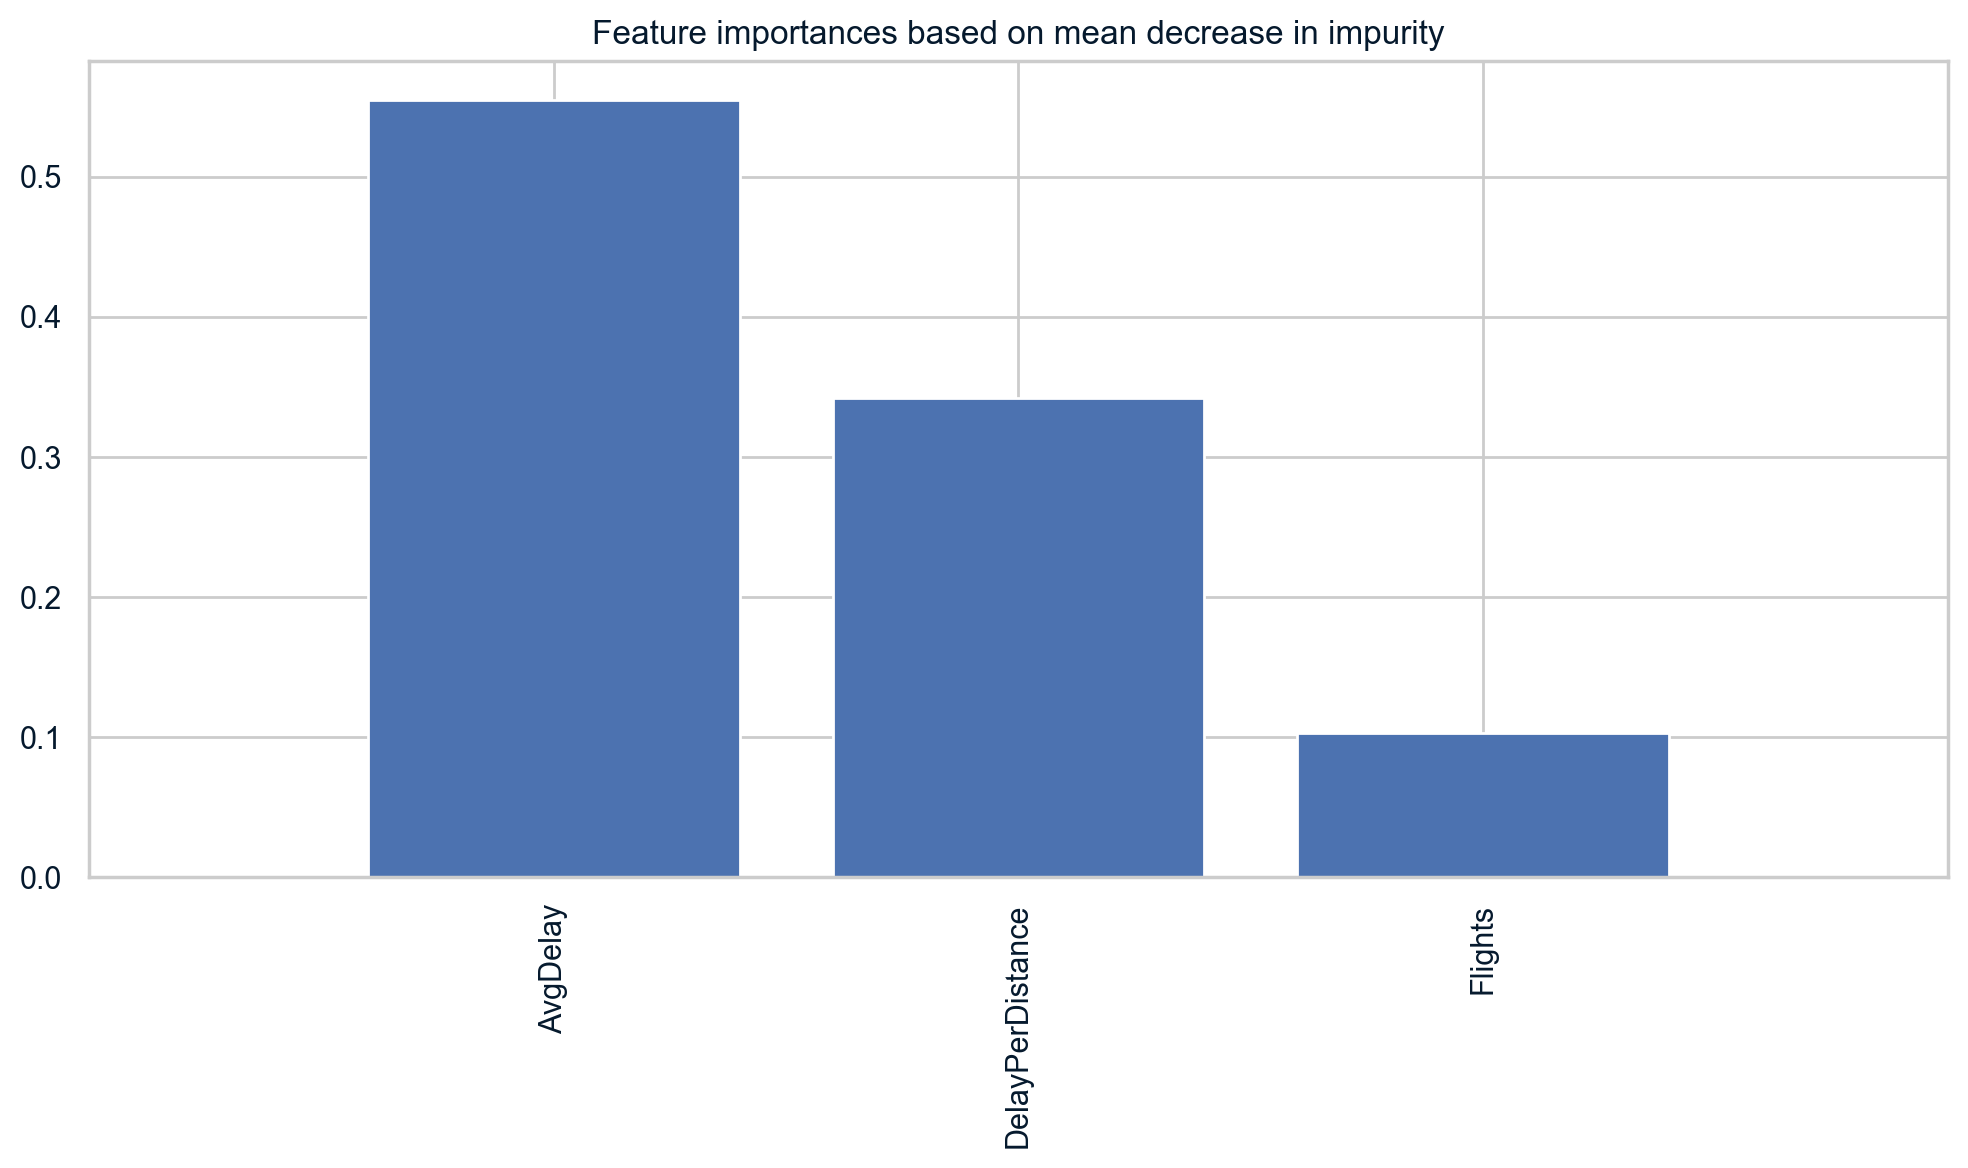

In [13]:
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Print the feature ranking
print("Feature ranking based on mean decrease in impurity:")
for f in range(X_train[selected_features].shape[1]):
    print(f"{f + 1}. {selected_features[indices[f]]} ({importances[indices[f]]})")

# Plot the feature importances of the forest
plt.figure(figsize=(10, 6))
plt.title("Feature importances based on mean decrease in impurity")
plt.bar(range(X_train[selected_features].shape[1]), importances[indices], align="center")
plt.xticks(range(X_train[selected_features].shape[1]), selected_features[indices], rotation=90)
plt.xlim([-1, X_train[selected_features].shape[1]])
plt.tight_layout()
plt.show()

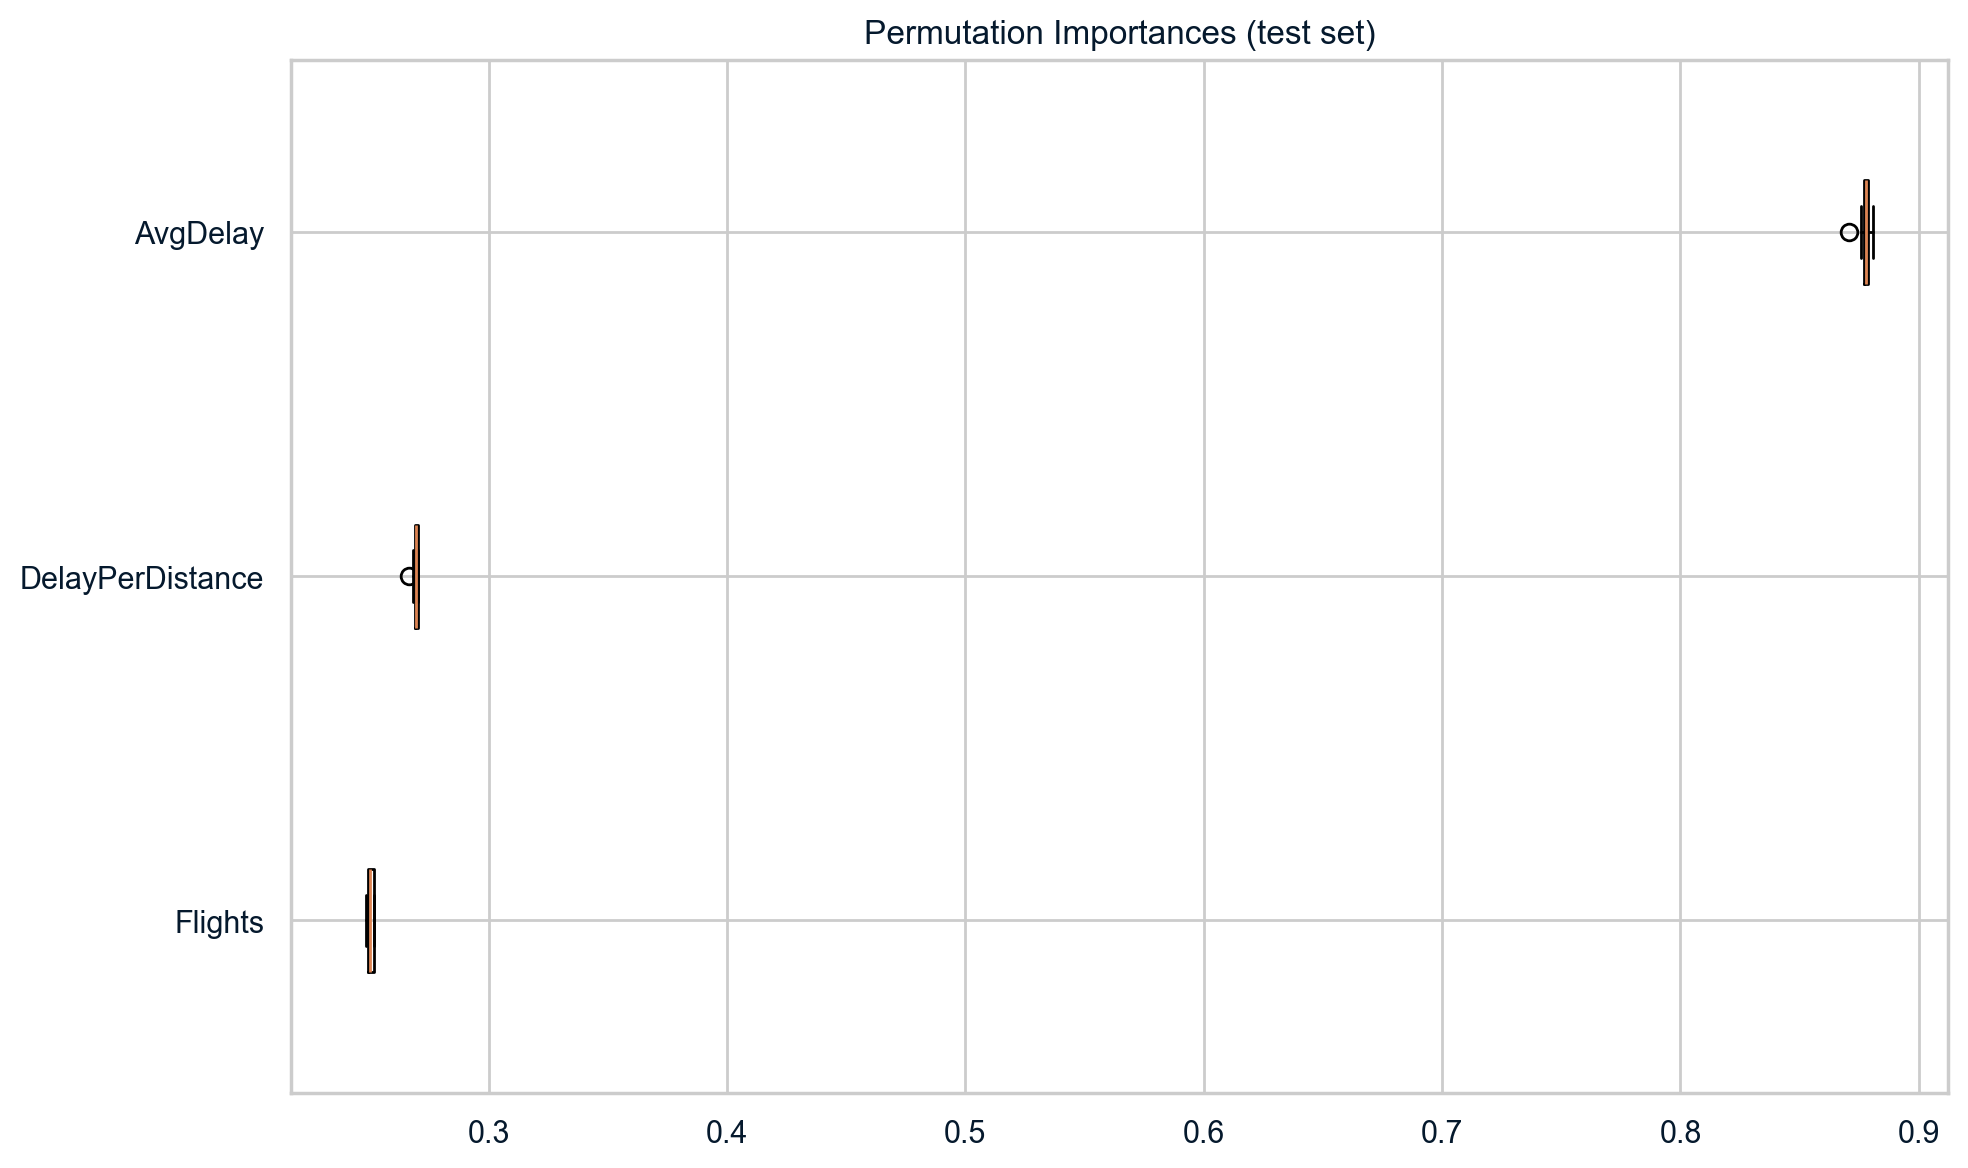

In [14]:
# Permutation importance
result = permutation_importance(model, X_test[selected_features].copy(), y_test, n_repeats=10, random_state=42, n_jobs=1)
perm_sorted_idx = result.importances_mean.argsort()

# Plot permutation importances
plt.figure(figsize=(10, 6))
plt.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X_test[selected_features].columns[perm_sorted_idx])
plt.title("Permutation Importances (test set)")
plt.tight_layout()
plt.show()

To predict flight delay using a time series approach, we need to consider the temporal aspect of the data. We'll use the `DATE` column to set up a time series model. For this example, we'll use the `statsmodels` library to create an ARIMA model, which is suitable for time series forecasting.

Let's start by preparing the data for time series analysis.

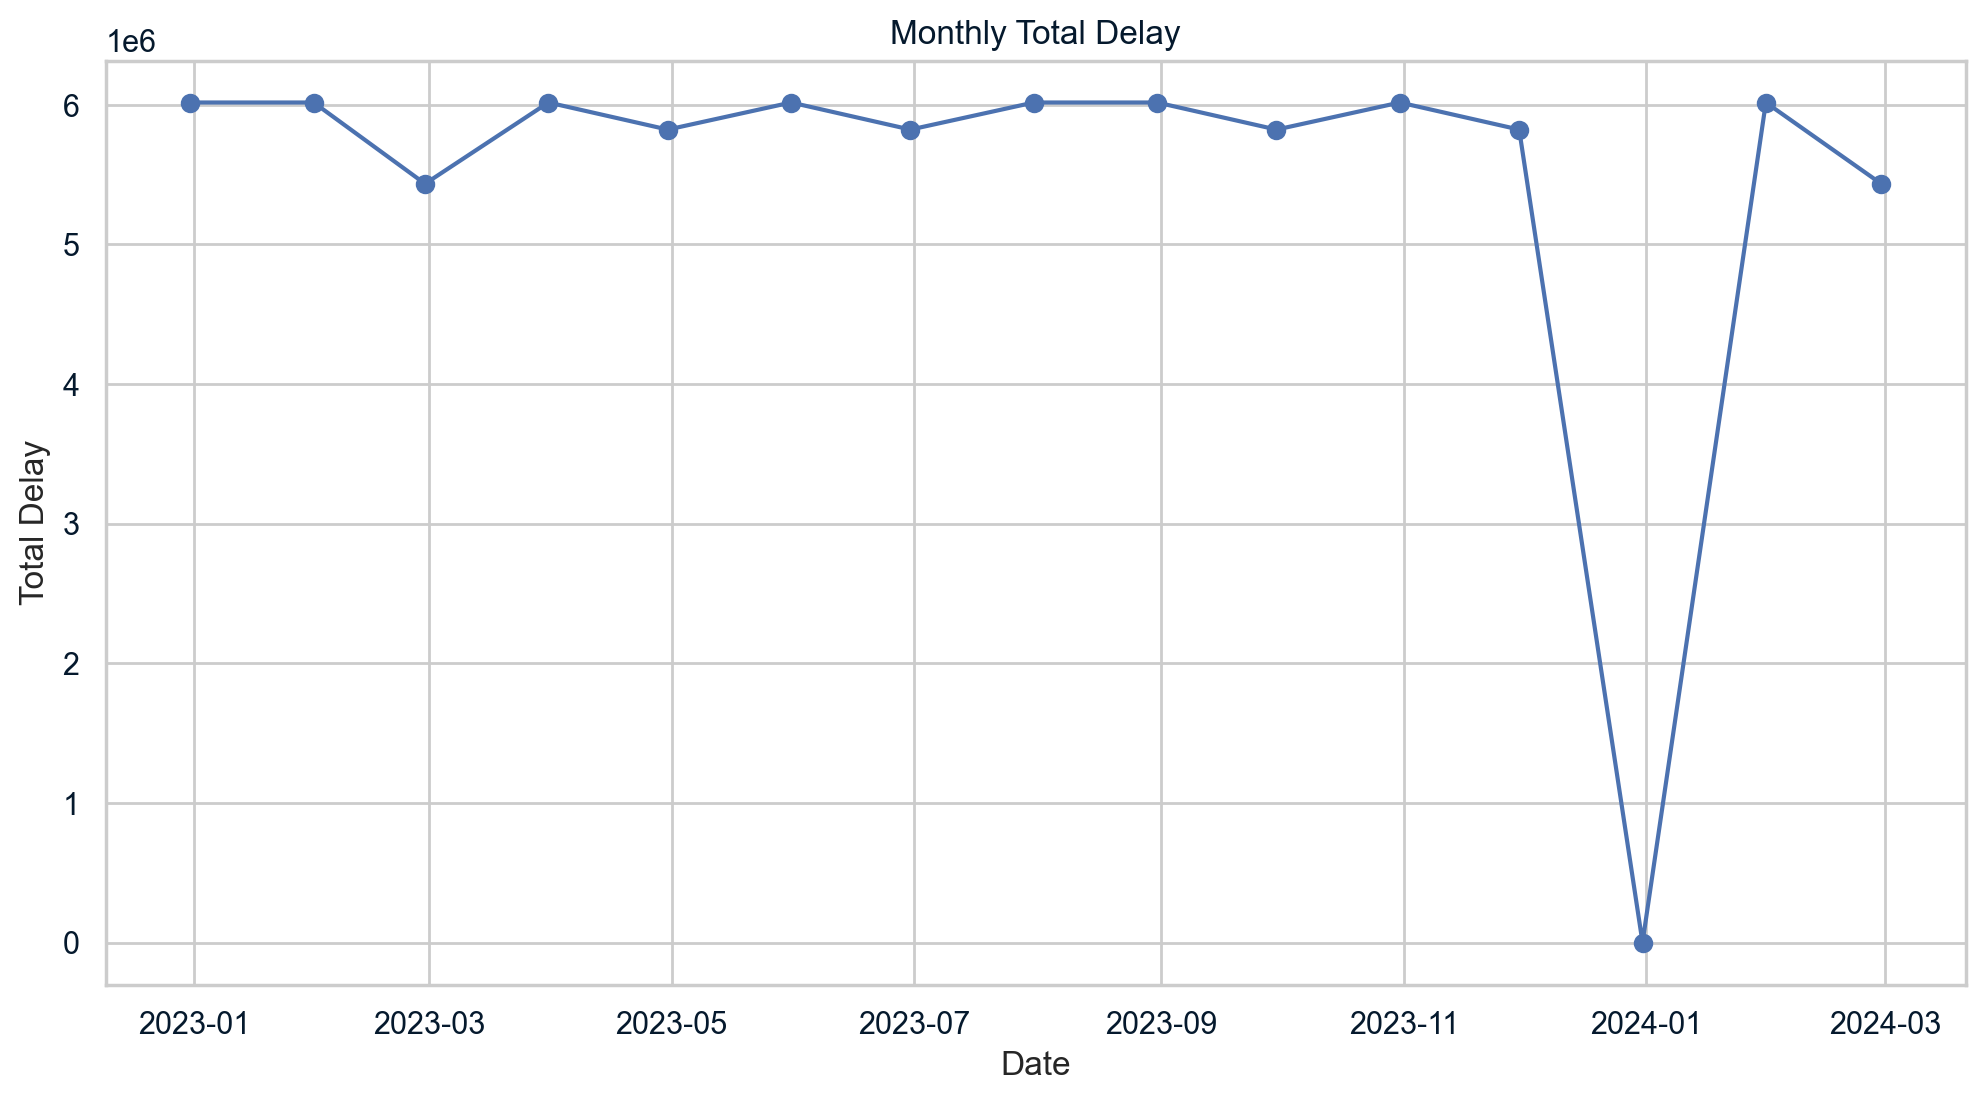

In [15]:
# Load the data
# Assuming 'merged_data.csv' is already loaded as 'data'

data['DATE'] = pd.to_datetime(data['DATE'])
data.set_index('DATE', inplace=True)

# Resample the data to monthly frequency, summing up the delays
monthly_data = data['TotalDelay'].resample('M').sum()

# Plot the time series
def plot_time_series(data, title):
    plt.figure(figsize=(12, 6))
    plt.plot(data, marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Total Delay')
    plt.grid(True)
    plt.show()

plot_time_series(monthly_data, 'Monthly Total Delay')

To predict flight delay per season over a period of 3 years using a time series approach, we need to aggregate the data by season and then apply a time series model. We'll use the `statsmodels` library to create an ARIMA model for this purpose.

Let's start by preparing the data for seasonal time series analysis.

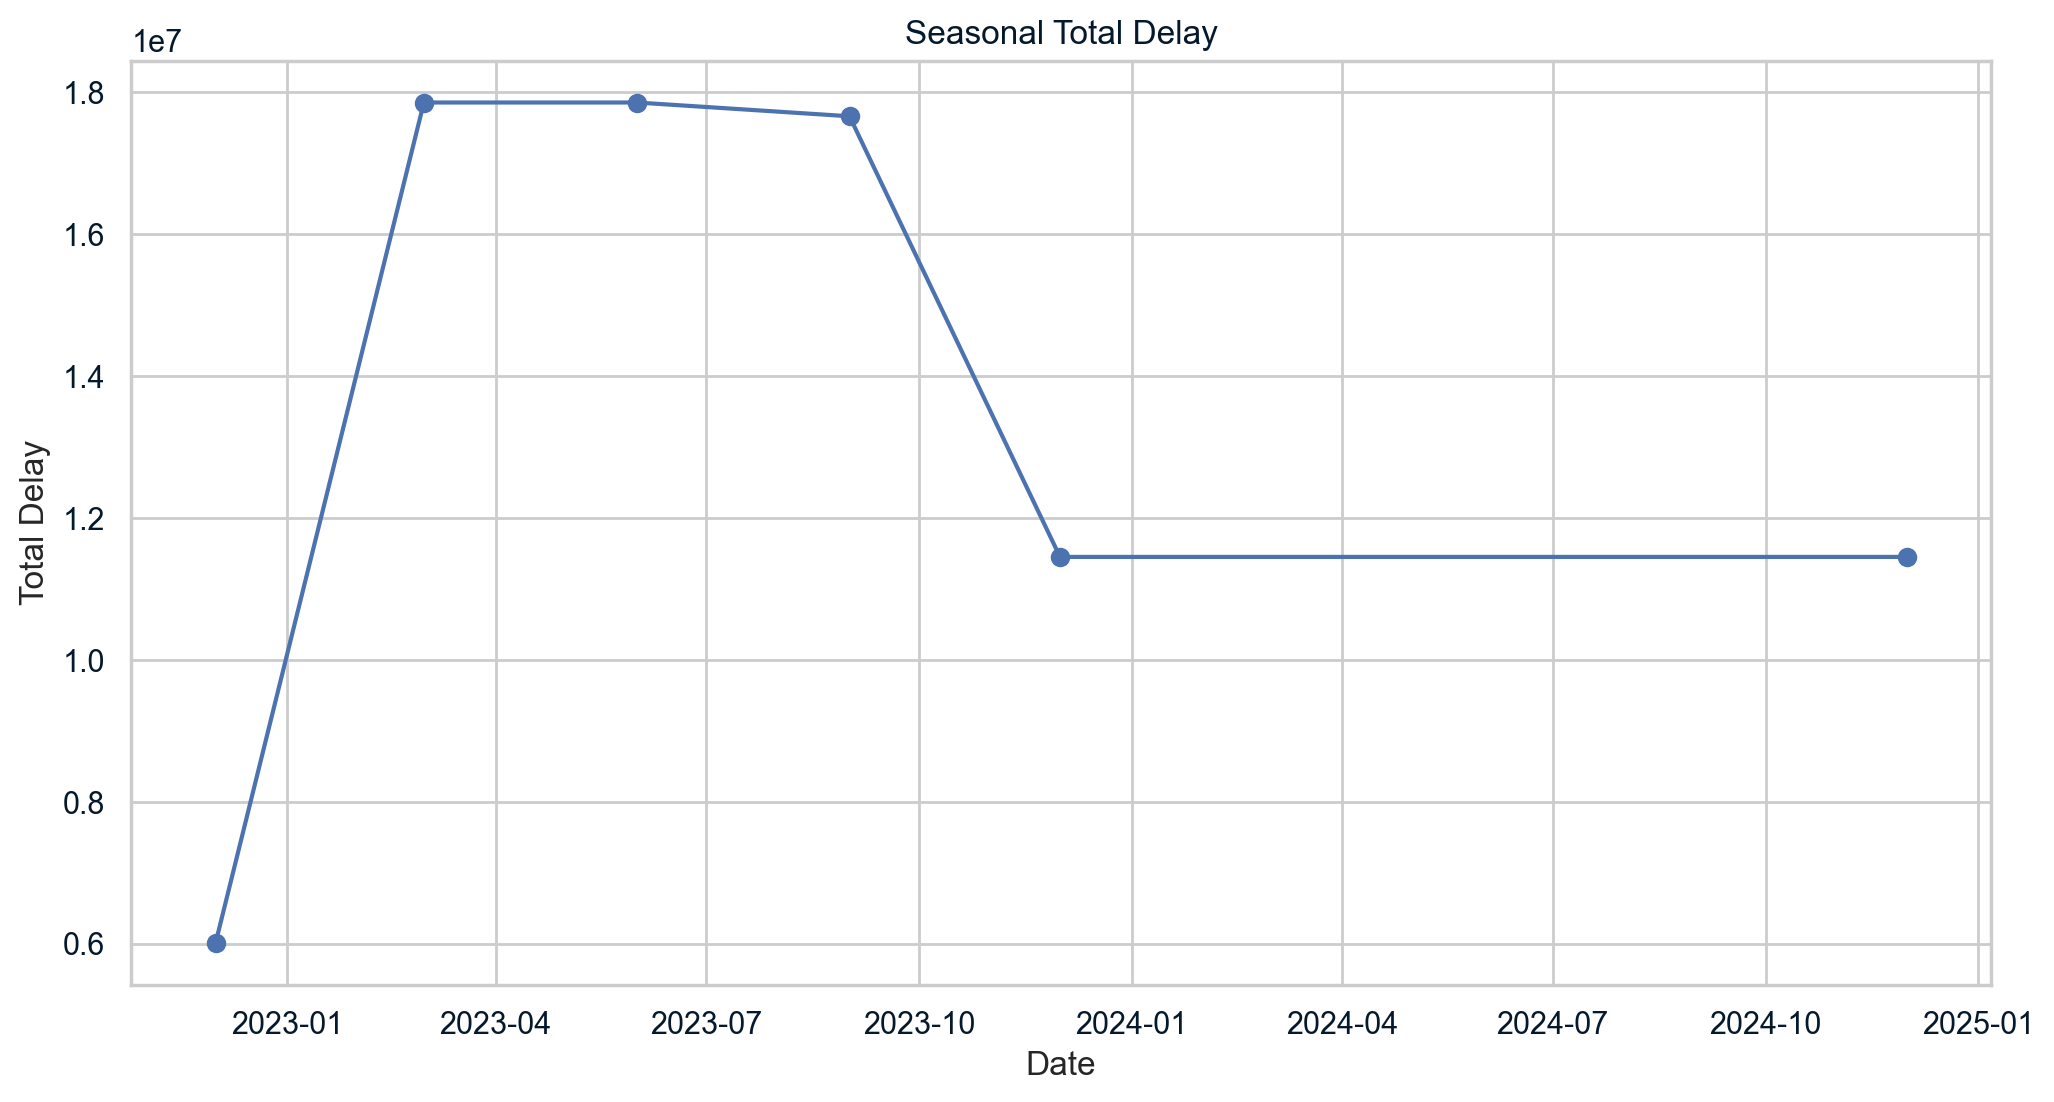

In [16]:
# Aggregate the data by season
seasonal_data = data.groupby(['Year', 'Season'])['TotalDelay'].sum().reset_index()

# Create a datetime index for the seasonal data
seasonal_data['Date'] = pd.to_datetime(seasonal_data['Year'].astype(str) + '-' + \
                                        seasonal_data['Season'].map({'Winter': '12', 'Spring': '03', 'Summer': '06', 'Fall': '09'}) + '-01')
seasonal_data.set_index('Date', inplace=True)

# Sort the data by date
seasonal_data.sort_index(inplace=True)

# Plot the seasonal time series
def plot_seasonal_time_series(data, title):
    plt.figure(figsize=(12, 6))
    plt.plot(data, marker='o', linestyle='-')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Total Delay')
    plt.grid(True)
    plt.show()

plot_seasonal_time_series(seasonal_data['TotalDelay'], 'Seasonal Total Delay')

To determine which airports are most likely to have flight delays, we can analyze the `TotalDelay` data for each airport. We'll calculate the average total delay per airport and identify those with the highest average delays.

In [17]:
# Load the data from the CSV file
file_path = 'merged_data.csv'
data = pd.read_csv(file_path)

# Calculate the average total delay per airport
average_delay_per_airport = data.groupby('Airport')['TotalDelay'].mean().sort_values(ascending=False)

# Display the top 5 airports with the highest average delays
average_delay_per_airport.head()

Airport
JFK    100.445000
DFW     98.685000
CLT     95.118571
MIA     93.218571
MCO     92.684286
Name: TotalDelay, dtype: float64

To visualize which airports are most likely to have flight delays, we can create a bar chart showing the average total delay for each airport. This will help us identify the airports with the highest average delays.

In [18]:
# Calculate the average total delay per airport
average_delay_per_airport = data.groupby('Airport')['TotalDelay'].mean().sort_values(ascending=False)

# Create a bar chart
fig = px.bar(
    average_delay_per_airport.head(10).reset_index(),
    x='Airport',
    y='TotalDelay',
    title='Top 10 Airports with Highest Average Total Delays',
    labels={'TotalDelay': 'Average Total Delay (minutes)'},
    template='plotly_dark'
)

# Show the plot
fig.show()

We will develop a Random Forest model to predict flight delays for a sample of 5 airports during the summer season. The `Delayed` column will be used as the target variable, where a delay time greater than 0 indicates a delay (`Delayed = 1`), and no delay time indicates no delay (`Delayed = 0`).

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Filter data for summer season
summer_data = data[data['Season'] == 'Summer']

# Select a sample of 5 airports
sample_airports = summer_data['Airport'].unique()[:5]
sample_data = summer_data[summer_data['Airport'].isin(sample_airports)]

# Define features and target
features = ['Flights', 'Distance', 'TEMP', 'PRCP', 'WIND', 'VISIBILITY', 'CEILING']
X = sample_data[features]
y = sample_data['Delayed']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

accuracy, report

(0.9211180124223602,
 '              precision    recall  f1-score   support\n\n           0       0.55      0.37      0.44      1626\n           1       0.94      0.97      0.96     17694\n\n    accuracy                           0.92     19320\n   macro avg       0.75      0.67      0.70     19320\nweighted avg       0.91      0.92      0.91     19320\n')

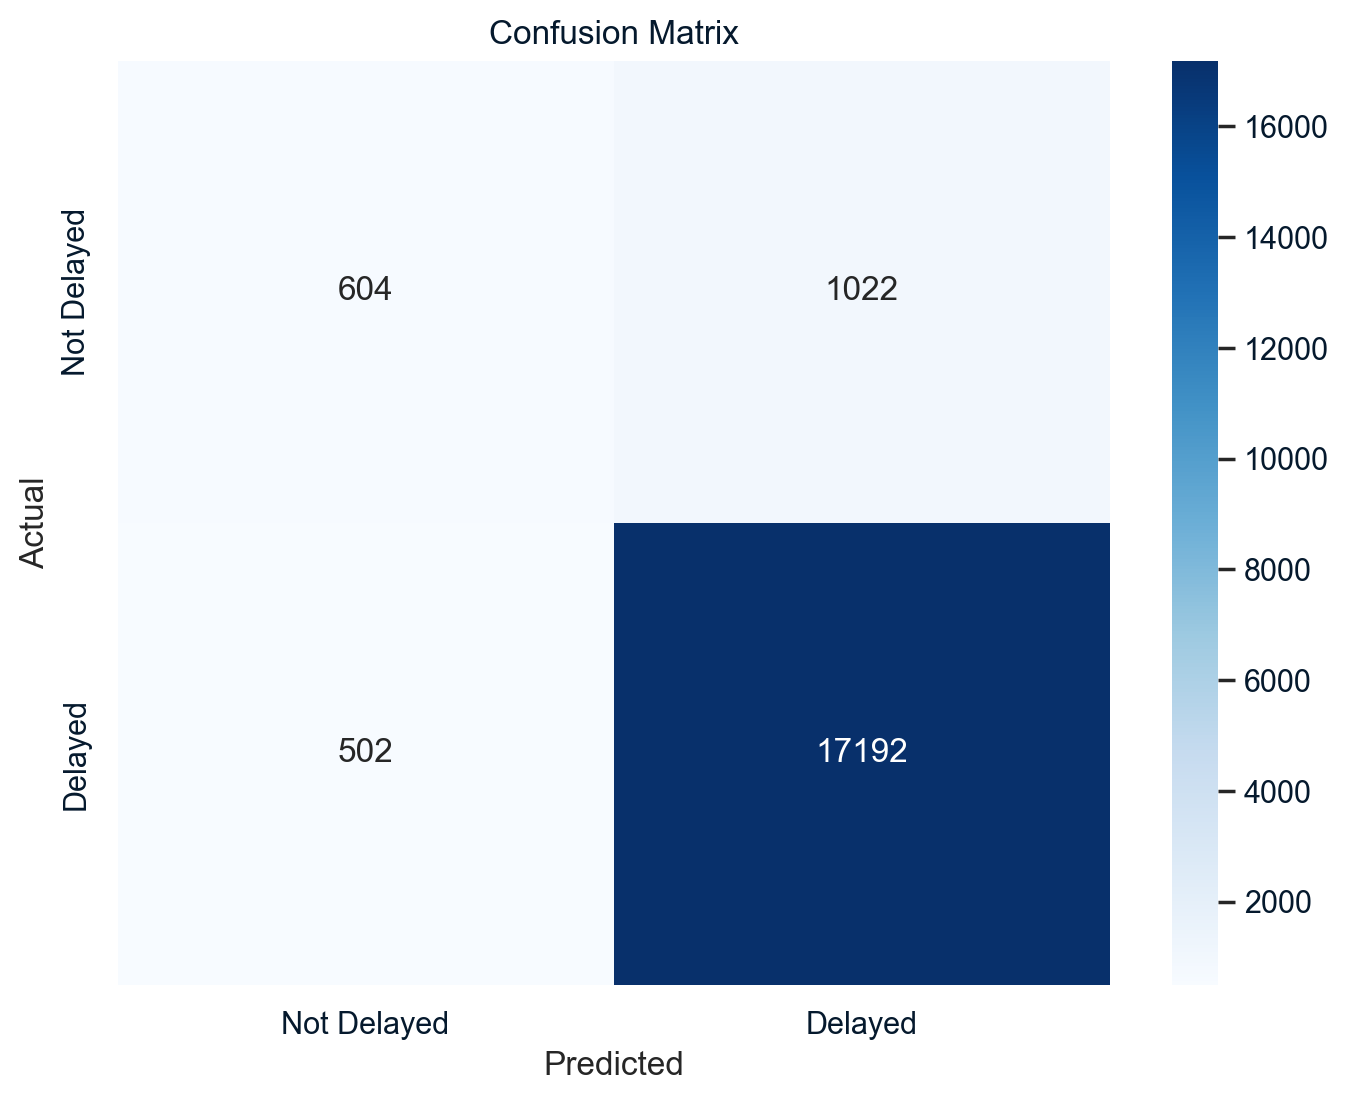

In [30]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Delayed', 'Delayed'], yticklabels=['Not Delayed', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Summary Report

This report provides an overview of the dataset and the results of the confusion matrix analysis for flight delay prediction.

## Dataset Overview

The dataset contains information about flights, including various features that may influence delays. Below is a summary of the key columns:

- **Flights**: Number of flights.
- **Distance**: Distance of the flight in miles.
- **TEMP**: Temperature at the origin airport.
- **PRCP**: Precipitation at the origin airport.
- **WIND**: Wind speed at the origin airport.
- **VISIBILITY**: Visibility at the origin airport.
- **CEILING**: Ceiling height at the origin airport.
- **Reporting_Airline**: Airline reporting the data.
- **Origin**: Origin airport code.
- **Dest**: Destination airport code.
- **AvgDelay**: Average delay in minutes.
- **DATE**: Date of the flight.
- **Year, Month, Day**: Date components.
- **Season**: Season of the year.
- **WeatherCondition**: Weather condition at the origin.
- **Airport**: Airport code.
- **TotalDelay**: Total delay in minutes.
- **DelayPerDistance**: Delay per mile.
- **IsWeekend**: Boolean indicating if the flight was on a weekend.
- **TemperatureCategory**: Categorical temperature range.
- **Delayed**: Binary indicator of whether the flight was delayed.

## Confusion Matrix Analysis

The confusion matrix provides insights into the performance of the flight delay prediction model. It compares the actual and predicted classifications of flight delays:

- **True Positives (TP)**: Flights correctly predicted as delayed.
- **True Negatives (TN)**: Flights correctly predicted as not delayed.
- **False Positives (FP)**: Flights incorrectly predicted as delayed.
- **False Negatives (FN)**: Flights incorrectly predicted as not delayed.

The confusion matrix is visualized using a heatmap, which helps in understanding the model's accuracy and areas for improvement.

## Conclusion

This analysis helps in identifying patterns and factors contributing to flight delays, which can be used to improve prediction models and enhance operational efficiency.